In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import openpyxl

In [2]:
df = pd.read_excel('LogoComparisonData.xlsx')

In [3]:
df.head()

,Applicant Logo,Previous Logo,SSIM,Color Similarity Score,Shape Complexity Score,Template Matching,Text Similarity Score
0,GiorgoArmani DunkinDonuts (fake).png,gucci.png,0.422474,49.788772,0.856932,0.092365,11
1,GiorgoArmani DunkinDonuts (fake).png,venus.png,0.363483,43.027191,0.932490,0.124720,17
2,GiorgoArmani DunkinDonuts (fake).png,t-mobile.png,0.397332,26.913052,0.873433,0.132396,16
3,GiorgoArmani DunkinDonuts (fake).png,drpepper.png,0.315049,17.180655,0.876244,0.118946,16
4,GiorgoArmani DunkinDonuts (fake).png,lv.png,0.378743,38.462226,0.859287,0.119022,0


## Text Similarity Issue
For this test Text Similarity Score ended up being a way better indicator than it usually is because name of original logo is in the title of the counterfeit. I decided to use Text Similarity being 100 as an indicator of a logo match. Although I'm sure it's not precise, it's just what I did for this first analysis. I created a column called 'match' and made the entries True if text similarity is 100, False otherwise.

For the next test I will prevent the code from comparing a counterfeit's name to anything since it's a giveaway. Then we can incorporate text similarity into the classification. Right now it's not playing a part.

In [4]:
df = df.assign(Match = lambda x: (x['Text Similarity Score'] == 100))
df

,Applicant Logo,Previous Logo,SSIM,Color Similarity Score,Shape Complexity Score,Template Matching,Text Similarity Score,Match
0,GiorgoArmani DunkinDonuts (fake).png,gucci.png,0.422474,49.788772,0.856932,0.092365,11,False
1,GiorgoArmani DunkinDonuts (fake).png,venus.png,0.363483,43.027191,0.932490,0.124720,17,False
2,GiorgoArmani DunkinDonuts (fake).png,t-mobile.png,0.397332,26.913052,0.873433,0.132396,16,False
3,GiorgoArmani DunkinDonuts (fake).png,drpepper.png,0.315049,17.180655,0.876244,0.118946,16,False
4,GiorgoArmani DunkinDonuts (fake).png,lv.png,0.378743,38.462226,0.859287,0.119022,0,False
...,...,...,...,...,...,...,...,...
14269,greyhound(fake).png,samsung(fake).png,0.542770,24.406560,0.902102,0.098706,54,False
14270,greyhound(fake).png,tokyo2020 (fake).png,0.592169,18.731523,0.901187,0.074972,50,False
14271,greyhound(fake).png,Chanel Champion (fake).png,0.667509,24.107286,0.863101,0.081106,47,False
14272,greyhound(fake).png,Puma Gucci (fake).png,0.603062,4.633276,0.875855,0.093654,48,False


## Now check that all the data are present and the right type

In [5]:
df.head()

,Applicant Logo,Previous Logo,SSIM,Color Similarity Score,Shape Complexity Score,Template Matching,Text Similarity Score,Match
0,GiorgoArmani DunkinDonuts (fake).png,gucci.png,0.422474,49.788772,0.856932,0.092365,11,False
1,GiorgoArmani DunkinDonuts (fake).png,venus.png,0.363483,43.027191,0.932490,0.124720,17,False
2,GiorgoArmani DunkinDonuts (fake).png,t-mobile.png,0.397332,26.913052,0.873433,0.132396,16,False
3,GiorgoArmani DunkinDonuts (fake).png,drpepper.png,0.315049,17.180655,0.876244,0.118946,16,False
4,GiorgoArmani DunkinDonuts (fake).png,lv.png,0.378743,38.462226,0.859287,0.119022,0,False


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14274 entries, 0 to 14273
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Applicant Logo          14274 non-null  object 
 1   Previous Logo           14274 non-null  object 
 2   SSIM                    14274 non-null  float64
 3   Color Similarity Score  14274 non-null  float64
 4   Shape Complexity Score  14274 non-null  float64
 5   Template Matching       14274 non-null  float64
 6   Text Similarity Score   14274 non-null  int64  
 7   Match                   14274 non-null  bool   
dtypes: bool(1), float64(4), int64(1), object(2)
memory usage: 794.7+ KB


In [7]:
#checking for null values
df.isnull().sum()

Applicant Logo            0
Previous Logo             0
SSIM                      0
Color Similarity Score    0
Shape Complexity Score    0
Template Matching         0
Text Similarity Score     0
Match                     0
dtype: int64

# Data visualization

In [8]:
df.head()

,Applicant Logo,Previous Logo,SSIM,Color Similarity Score,Shape Complexity Score,Template Matching,Text Similarity Score,Match
0,GiorgoArmani DunkinDonuts (fake).png,gucci.png,0.422474,49.788772,0.856932,0.092365,11,False
1,GiorgoArmani DunkinDonuts (fake).png,venus.png,0.363483,43.027191,0.932490,0.124720,17,False
2,GiorgoArmani DunkinDonuts (fake).png,t-mobile.png,0.397332,26.913052,0.873433,0.132396,16,False
3,GiorgoArmani DunkinDonuts (fake).png,drpepper.png,0.315049,17.180655,0.876244,0.118946,16,False
4,GiorgoArmani DunkinDonuts (fake).png,lv.png,0.378743,38.462226,0.859287,0.119022,0,False


## Obviously the data are super imbalanced. What's the expected rate of fraud in future logos? Does it matter?

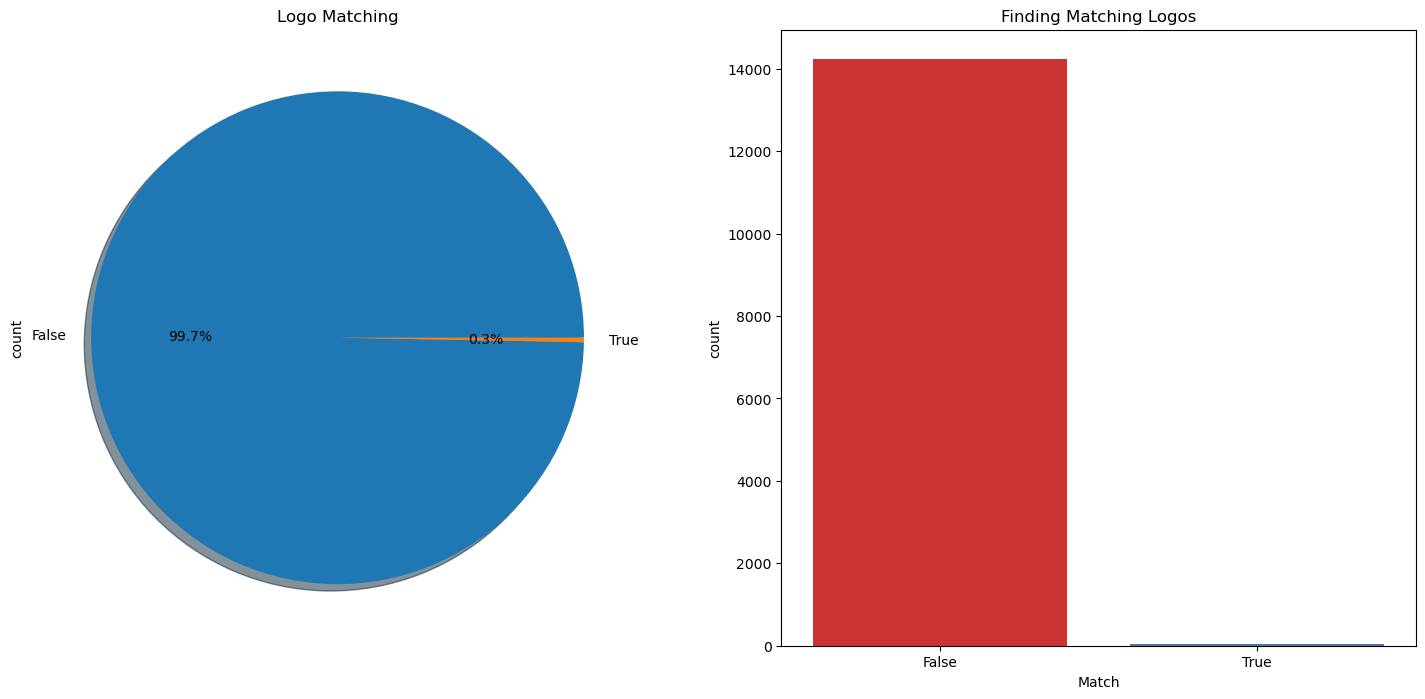

In [9]:
f,ax=plt.subplots(1,2,figsize=(18,8))

ax[0] = df['Match'].value_counts().plot.pie(explode=[0,0],autopct='%1.1f%%',ax=ax[0],shadow=True)
ax[0].set_title('Logo Matching')


#f, ax = plt.subplots(figsize=(6, 8))
ax[1] = sns.countplot(x="Match", data=df, palette="Set1")
ax[1].set_title("Finding Matching Logos")

plt.show()

In [10]:
df['Match'].value_counts()/len(df)

Match
False    0.997128
True     0.002872
Name: count, dtype: float64

In [11]:
is_a_match = df[df['Match'] == True]
not_a_match = df[df['Match'] == False]
print ("There are", is_a_match.shape[0], "matches among",  not_a_match.shape[0], "original logos")

There are 41 matches among 14233 original logos


Since it is highy imbalanced  the machine learning algorithm we use may get biased. It would underpredict the minority, which is exactly the opposite of what we're trying to do. We will try to balance this dataset later .

Now let's visualize the average similarity scores for matching and non matching logo comparisons

In [12]:
# Group together the approved logos and the flagged logos
grouped = df.groupby('Match').mean(numeric_only=True)

# Change index from boolean to meaning
grouped = grouped.rename(index = {True: 'Flagged', False: 'Approved'})

# Make every score on a scale from 0-100
grouped['SSIM'] *= 100
grouped['Shape Complexity Score'] *= 100
grouped['Template Matching'] *= 100
grouped

,SSIM,Color Similarity Score,Shape Complexity Score,Template Matching,Text Similarity Score
Match,,,,,
Approved,32.120523,32.424638,82.108918,12.900351,26.207897
Flagged,49.174078,22.783697,87.169349,12.928492,100.000000


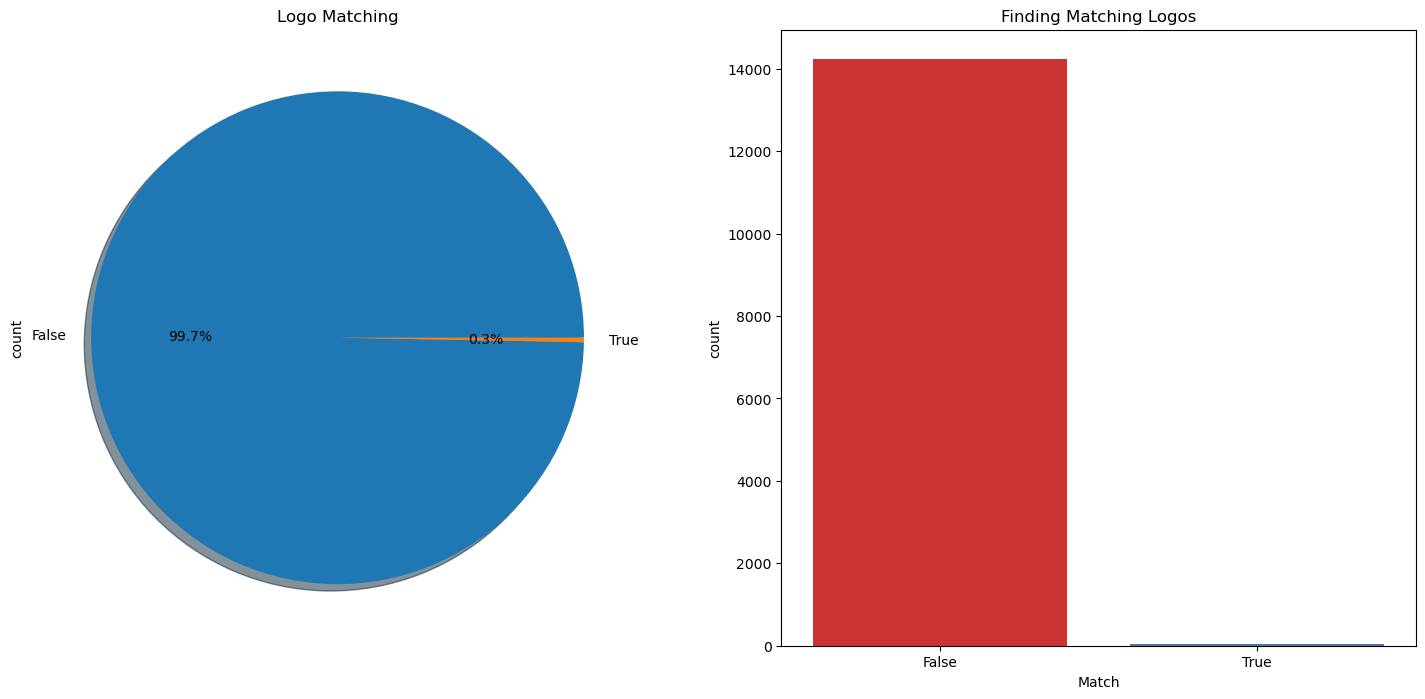

In [13]:
f,ax=plt.subplots(1,2,figsize=(18,8))

ax[0] = df['Match'].value_counts().plot.pie(explode=[0,0],autopct='%1.1f%%',ax=ax[0],shadow=True)
ax[0].set_title('Logo Matching')


#f, ax = plt.subplots(figsize=(6, 8))
ax[1] = sns.countplot(x="Match", data=df, palette="Set1")
ax[1].set_title("Finding Matching Logos")

plt.show()

In [14]:
grouped

,SSIM,Color Similarity Score,Shape Complexity Score,Template Matching,Text Similarity Score
Match,,,,,
Approved,32.120523,32.424638,82.108918,12.900351,26.207897
Flagged,49.174078,22.783697,87.169349,12.928492,100.000000


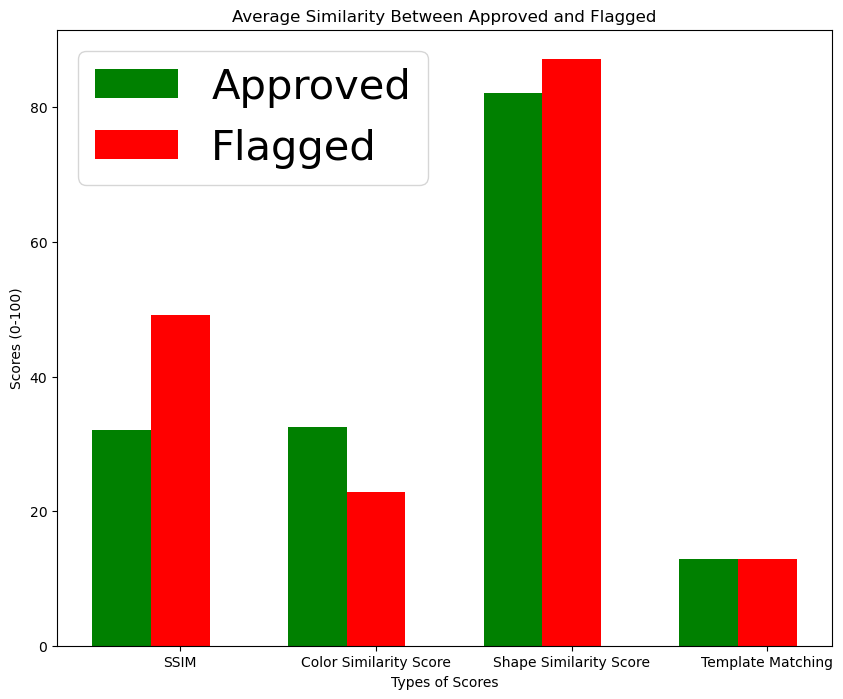

In [15]:
ind = np.arange(4)  
width = 0.3

plt.figure(figsize=(10, 8))
  
xvals = grouped.loc['Approved'][:4]
bar1 = plt.bar(ind, xvals, width, color = 'g') 
  
yvals = grouped.loc['Flagged'][:4]
bar2 = plt.bar(ind+width, yvals, width, color='r') 
  
plt.xlabel('Types of Scores') 
plt.ylabel('Scores (0-100)') 
plt.title('Average Similarity Between Approved and Flagged') 
  
plt.xticks(ind+width,['SSIM', 'Color Similarity Score', 'Shape Similarity Score', 'Template Matching']) 
plt.legend( (bar1, bar2), ('Approved', 'Flagged'), loc='upper left', fontsize=30) 
plt.show()

In [16]:
df.head()

,Applicant Logo,Previous Logo,SSIM,Color Similarity Score,Shape Complexity Score,Template Matching,Text Similarity Score,Match
0,GiorgoArmani DunkinDonuts (fake).png,gucci.png,0.422474,49.788772,0.856932,0.092365,11,False
1,GiorgoArmani DunkinDonuts (fake).png,venus.png,0.363483,43.027191,0.932490,0.124720,17,False
2,GiorgoArmani DunkinDonuts (fake).png,t-mobile.png,0.397332,26.913052,0.873433,0.132396,16,False
3,GiorgoArmani DunkinDonuts (fake).png,drpepper.png,0.315049,17.180655,0.876244,0.118946,16,False
4,GiorgoArmani DunkinDonuts (fake).png,lv.png,0.378743,38.462226,0.859287,0.119022,0,False


We see people who have done masters are earning less than students who have just cleared their high school which is not normal. Let's try to observe more on these people

### Checking the individual similarity scores for outliers

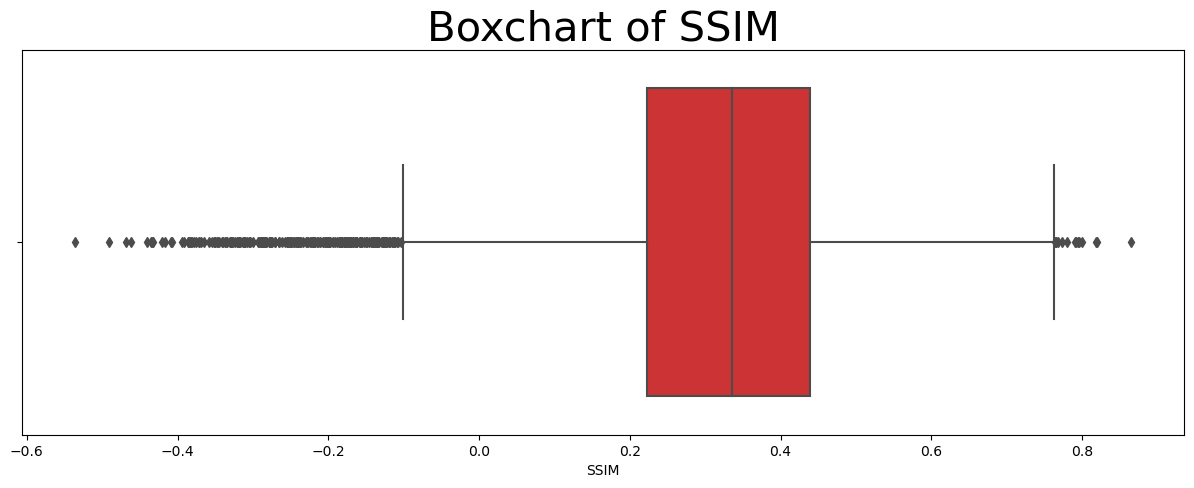

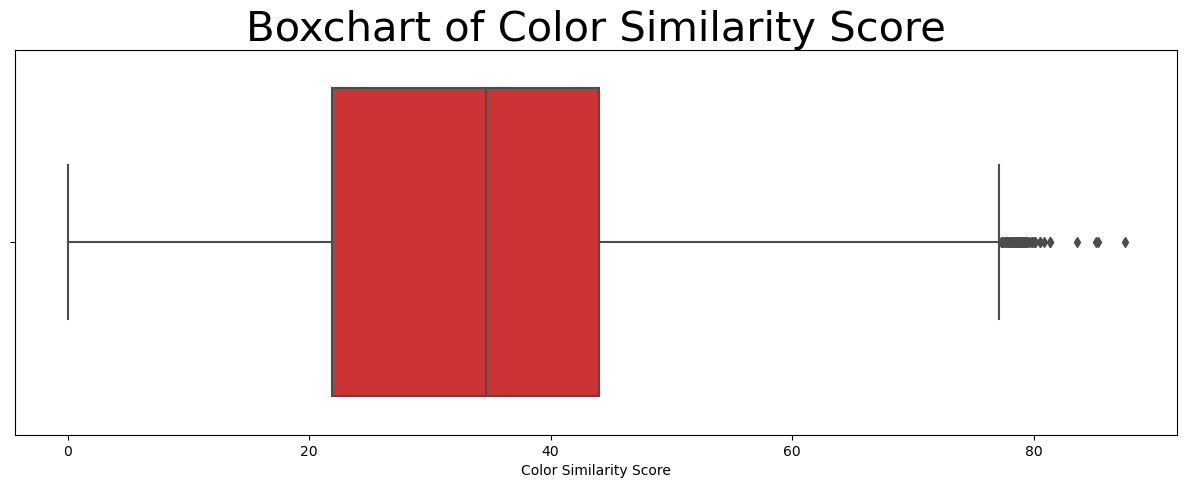

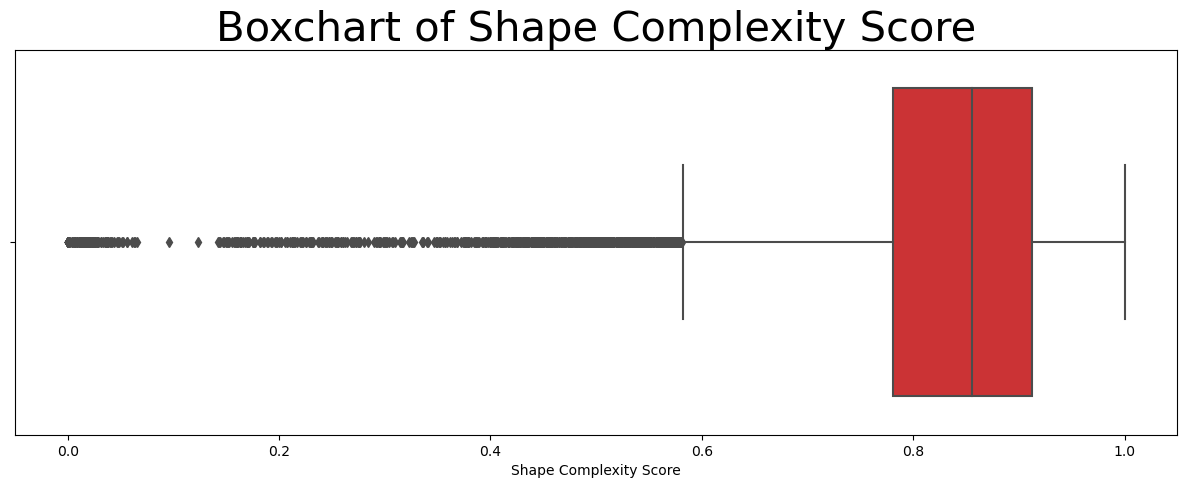

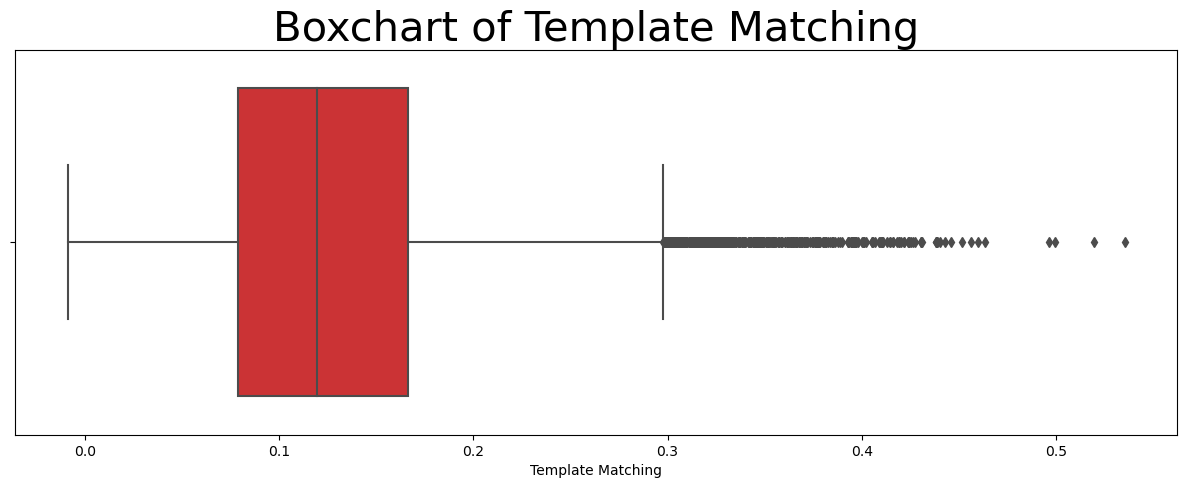

In [17]:
features = ['SSIM', 'Color Similarity Score', 'Shape Complexity Score', 'Template Matching']

for i in features:
    plt.figure(figsize=[15, 5])
    sns.boxplot(x = df[i][1:],data=df.iloc[1:], order=df[i][1:].value_counts().index, palette='Set1')
    plt.title("Boxchart of {}".format(i), fontsize=30)
    plt.show()


/var/folders/04/m_rmq6013ln6qkmx48cqwnjh0000gn/T/ipykernel_49336/819431307.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(x=df[i], palette='Set1',bins=20)


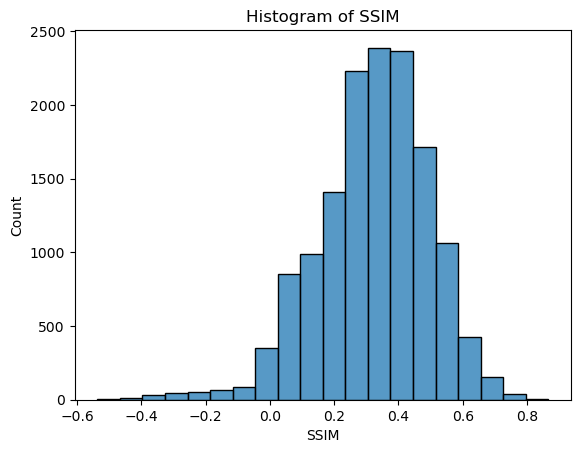

/var/folders/04/m_rmq6013ln6qkmx48cqwnjh0000gn/T/ipykernel_49336/819431307.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(x=df[i], palette='Set1',bins=20)


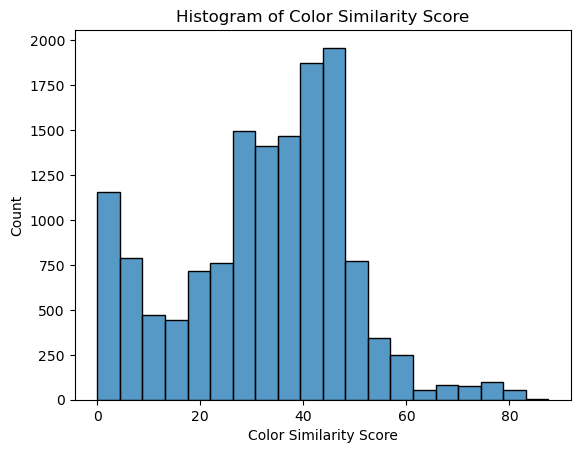

/var/folders/04/m_rmq6013ln6qkmx48cqwnjh0000gn/T/ipykernel_49336/819431307.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(x=df[i], palette='Set1',bins=20)


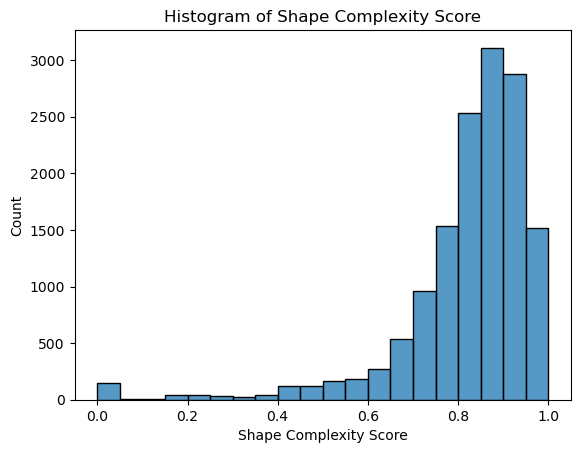

/var/folders/04/m_rmq6013ln6qkmx48cqwnjh0000gn/T/ipykernel_49336/819431307.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(x=df[i], palette='Set1',bins=20)


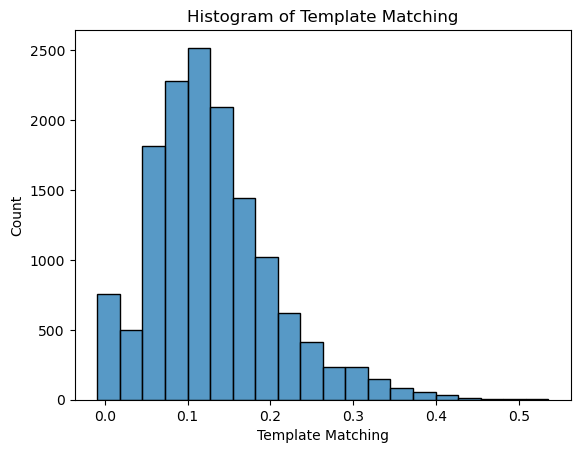

In [18]:
for i in features:
    sns.histplot(x=df[i], palette='Set1',bins=20)
    plt.title("Histogram of {}".format(i))
    plt.show()


In [19]:
distributions = df.copy()[['SSIM', 'Color Similarity Score', 'Shape Complexity Score', 'Template Matching', 'Match']]
distributions

,SSIM,Color Similarity Score,Shape Complexity Score,Template Matching,Match
0,0.422474,49.788772,0.856932,0.092365,False
1,0.363483,43.027191,0.932490,0.124720,False
2,0.397332,26.913052,0.873433,0.132396,False
3,0.315049,17.180655,0.876244,0.118946,False
4,0.378743,38.462226,0.859287,0.119022,False
...,...,...,...,...,...
14269,0.542770,24.406560,0.902102,0.098706,False
14270,0.592169,18.731523,0.901187,0.074972,False
14271,0.667509,24.107286,0.863101,0.081106,False
14272,0.603062,4.633276,0.875855,0.093654,False


/Users/aaronrasin/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


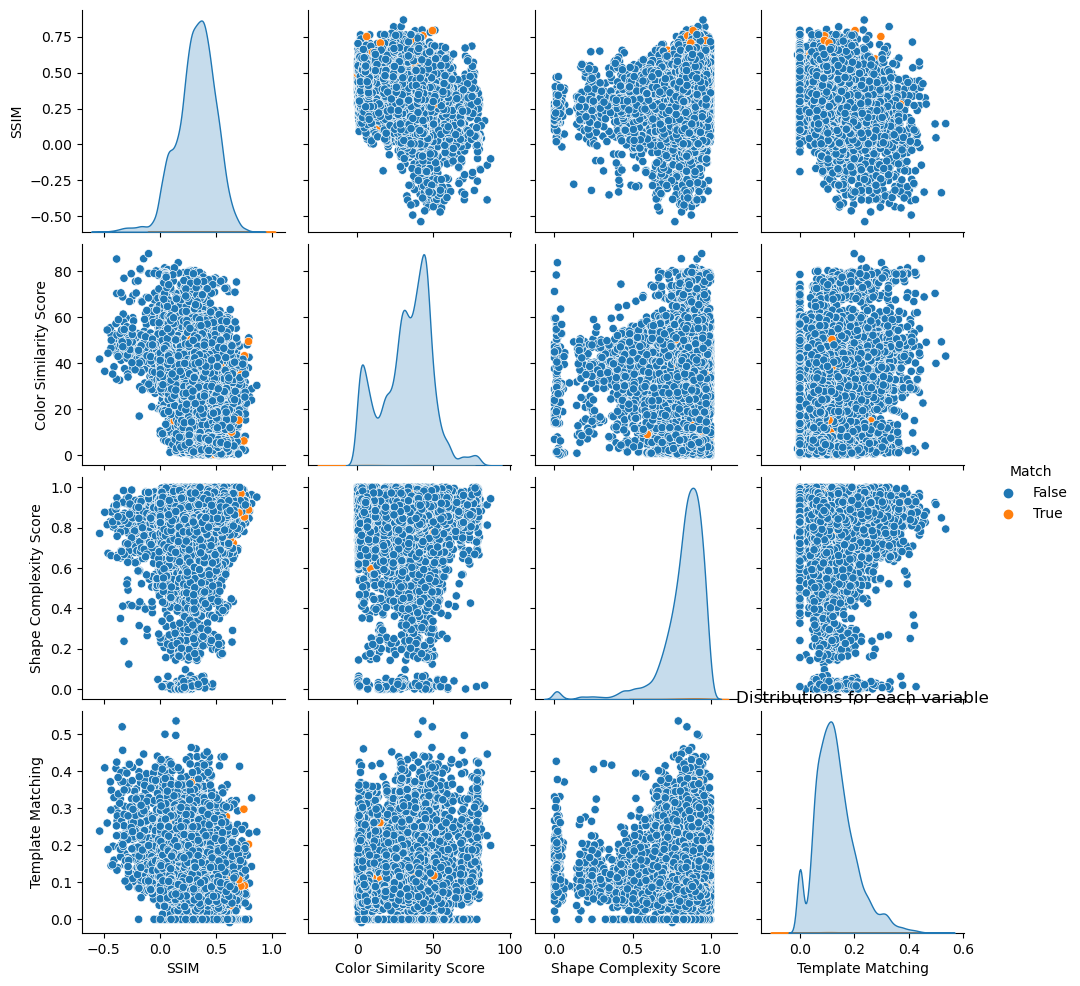

In [20]:
sns.pairplot(data=distributions, hue='Match')
plt.title('Distributions for each variable')
plt.show()

# Normalizing the variables 

In [21]:
from sklearn.preprocessing import MinMaxScaler

In [22]:
scaler = MinMaxScaler()

In [23]:
df.head()

,Applicant Logo,Previous Logo,SSIM,Color Similarity Score,Shape Complexity Score,Template Matching,Text Similarity Score,Match
0,GiorgoArmani DunkinDonuts (fake).png,gucci.png,0.422474,49.788772,0.856932,0.092365,11,False
1,GiorgoArmani DunkinDonuts (fake).png,venus.png,0.363483,43.027191,0.932490,0.124720,17,False
2,GiorgoArmani DunkinDonuts (fake).png,t-mobile.png,0.397332,26.913052,0.873433,0.132396,16,False
3,GiorgoArmani DunkinDonuts (fake).png,drpepper.png,0.315049,17.180655,0.876244,0.118946,16,False
4,GiorgoArmani DunkinDonuts (fake).png,lv.png,0.378743,38.462226,0.859287,0.119022,0,False


In [24]:
scaler.fit(df.drop(['Applicant Logo','Previous Logo', 'Text Similarity Score', 'Match'],axis=1))

MinMaxScaler()

In [25]:
scaled_features = scaler.transform(df.drop(['Applicant Logo','Previous Logo', 'Text Similarity Score', 'Match'],axis=1))

In [26]:
# Numeric columns
columns=list(df.columns.values)[2:-2]
columns

['SSIM',
 'Color Similarity Score',
 'Shape Complexity Score',
 'Template Matching']

In [27]:
df_scaled = pd.DataFrame(scaled_features,columns=columns)
df_scaled.head()

,SSIM,Color Similarity Score,Shape Complexity Score,Template Matching
0,0.683924,0.568800,0.856932,0.186135
1,0.641856,0.491554,0.932490,0.245588
2,0.665994,0.307462,0.873433,0.259693
3,0.607317,0.196276,0.876244,0.234979
4,0.652738,0.439403,0.859287,0.235118


# Handling Imbalanced dataset

In [28]:
from imblearn.combine import SMOTETomek
from imblearn.under_sampling import NearMiss

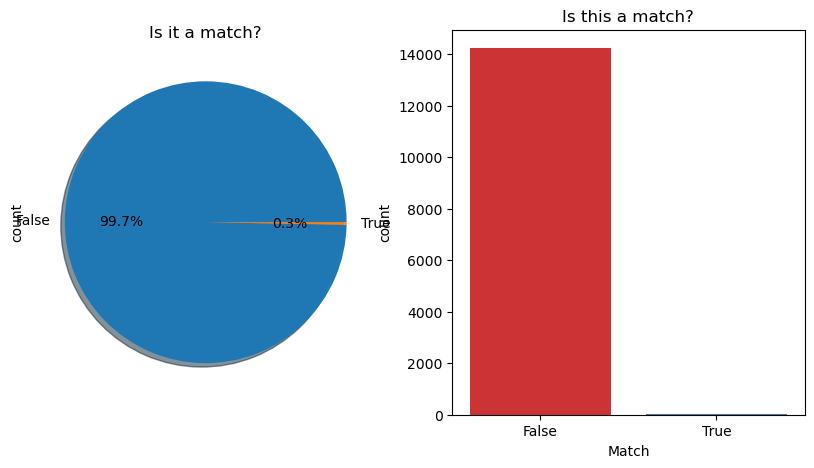

In [29]:
f,ax=plt.subplots(1,2,figsize=(10,5))

ax[0] = df['Match'].value_counts().plot.pie(explode=[0,0],autopct='%1.1f%%',ax=ax[0],shadow=True)
ax[0].set_title('Is it a match?')

ax[1] = sns.countplot(x="Match", data=df, palette="Set1")
ax[1].set_title("Is this a match?")

plt.show()

### Using over sampling method to handle imbalanced dataset

In [30]:
df.head()

,Applicant Logo,Previous Logo,SSIM,Color Similarity Score,Shape Complexity Score,Template Matching,Text Similarity Score,Match
0,GiorgoArmani DunkinDonuts (fake).png,gucci.png,0.422474,49.788772,0.856932,0.092365,11,False
1,GiorgoArmani DunkinDonuts (fake).png,venus.png,0.363483,43.027191,0.932490,0.124720,17,False
2,GiorgoArmani DunkinDonuts (fake).png,t-mobile.png,0.397332,26.913052,0.873433,0.132396,16,False
3,GiorgoArmani DunkinDonuts (fake).png,drpepper.png,0.315049,17.180655,0.876244,0.118946,16,False
4,GiorgoArmani DunkinDonuts (fake).png,lv.png,0.378743,38.462226,0.859287,0.119022,0,False


In [31]:
X = df_scaled
y= df.Match
X.head()

,SSIM,Color Similarity Score,Shape Complexity Score,Template Matching
0,0.683924,0.568800,0.856932,0.186135
1,0.641856,0.491554,0.932490,0.245588
2,0.665994,0.307462,0.873433,0.259693
3,0.607317,0.196276,0.876244,0.234979
4,0.652738,0.439403,0.859287,0.235118


In [32]:
# Implementing Oversampling for Handling Imbalanced Data
smk = SMOTETomek(random_state=42)
X_res,y_res=smk.fit_resample(X,y)
X_res.shape,y_res.shape

((28464, 4), (28464,))

In [33]:
from collections import Counter
print('Original dataset shape {}'.format(Counter(y)))
print('Resampled dataset shape {}'.format(Counter(y_res)))

Original dataset shape Counter({False: 14233, True: 41})
Resampled dataset shape Counter({False: 14232, True: 14232})


# Split the data into training and testing sets

In [34]:
from sklearn.model_selection import train_test_split

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X_res,y_res,test_size=0.2,random_state=101,shuffle=True)

In [36]:
print("X_train shape:",X_train.shape)
print("X_test shape:",X_test.shape)
print("y_train shape:",y_train.shape)
print("y_test shape:",y_test.shape)

X_train shape: (22771, 4)
X_test shape: (5693, 4)
y_train shape: (22771,)
y_test shape: (5693,)


# Building Models

## Gradient Boosting

In [37]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.calibration import CalibratedClassifierCV

In [38]:
%%time
gradient_booster = GradientBoostingClassifier(learning_rate=0.1)
accuracies = cross_val_score(gradient_booster, X_train, y_train, cv=5)
gradient_booster.fit(X_train,y_train)

print("Train Score:",np.mean(accuracies))
print("Test Score:",gradient_booster.score(X_test,y_test))

Train Score: 0.9058452611833989
Test Score: 0.9169155102757772
CPU times: user 22.4 s, sys: 362 ms, total: 22.7 s
Wall time: 23.8 s


In [39]:
%%time
grid = {
    'learning_rate':[0.01,0.05,0.1],
    'n_estimators':np.arange(100,500,100),
}

gb = GradientBoostingClassifier()
gb_cv = GridSearchCV(gb, grid, cv = 4)
gb_cv.fit(X_train,y_train)
print("Best Parameters:",gb_cv.best_params_)
print("Train Score:",gb_cv.best_score_)
print("Test Score:",gb_cv.score(X_test,y_test))

Best Parameters: {'learning_rate': 0.1, 'n_estimators': 400}
Train Score: 0.9488383439044806
Test Score: 0.9555594589847181
CPU times: user 7min 3s, sys: 7.47 s, total: 7min 11s
Wall time: 7min 47s


## Support Vector Classification (SVC)

In [41]:
from sklearn.svm import SVC
svc = SVC(random_state = 101)
accuracies = cross_val_score(svc, X_train, y_train, cv=5)
svc.fit(X_train,y_train)

print("Train Score:",np.mean(accuracies))
print("Test Score:",svc.score(X_test,y_test))

Train Score: 0.7739670460149628
Test Score: 0.7969436149657474


In [ ]:
# ### WARNING! Long Runtime ###

# grid = {
#     'C':[0.01,0.1,1,10],
#     'kernel' : ["linear","poly","rbf","sigmoid"],
#     'degree' : [1,3,5,7],
#     'gamma' : [0.01,1]
# }

# svm  = SVC ()
# svm_cv = GridSearchCV(svm, grid, cv = 5)
# svm_cv.fit(X_train,y_train)
# print("Best Parameters:",svm_cv.best_params_)
# print("Train Score:",svm_cv.best_score_)
# print("Test Score:",svm_cv.score(X_test,y_test))

## Naive Bayes

In [42]:
from sklearn.naive_bayes import GaussianNB
classifier = GaussianNB()
accuracies = cross_val_score(classifier, X_train, y_train, cv=5)
classifier.fit(X_train, y_train)

print("Train Score:",np.mean(accuracies))
print("Test Score:",classifier.score(X_test,y_test))

Train Score: 0.7106845768813029
Test Score: 0.7113999648691376


## Logistic Regression

In [43]:
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(max_iter=5000)
accuracies = cross_val_score(lr_model, X_train, y_train, cv=5)
lr_model.fit(X_train, y_train)

print("Train Score:",np.mean(accuracies))
print("Test Score:",lr_model.score(X_test,y_test))

Train Score: 0.7218393354631603
Test Score: 0.7235201124187599


In [ ]:
c_space = np.logspace(-5, 8, 15)
param_grid = {'C': c_space}
  
# Instantiating logistic regression classifier
logreg = LogisticRegression(max_iter=4000)
  
# Instantiating the GridSearchCV object
logreg_cv = GridSearchCV(logreg, param_grid, cv = 5)
logreg_cv.fit(X_train, y_train)

print("Best Parameters:",logreg_cv.best_params_)
print("Train Score:",logreg_cv.best_score_)
print("Test Score:",logreg_cv.score(X_test,y_test))

## Decision Tree
Decision tree so far has the most accurate predictions. See below for implementation and visualization.

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn import tree
from sklearn import metrics

In [96]:
%%time
# Create Decision Tree classifer object
dtc = DecisionTreeClassifier(max_depth=4)

# Train Decision Tree Classifer
dtc = dtc.fit(X_train,y_train)

#Predict the response for test dataset
y_pred = dtc.predict(X_test)

# Model Accuracy
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))

Accuracy: 0.7839451958545582
CPU times: user 73.9 ms, sys: 4.33 ms, total: 78.3 ms
Wall time: 89.8 ms


## Decision Tree Visualization

In [102]:
text_representation = tree.export_text(dtc)
# print(text_representation)

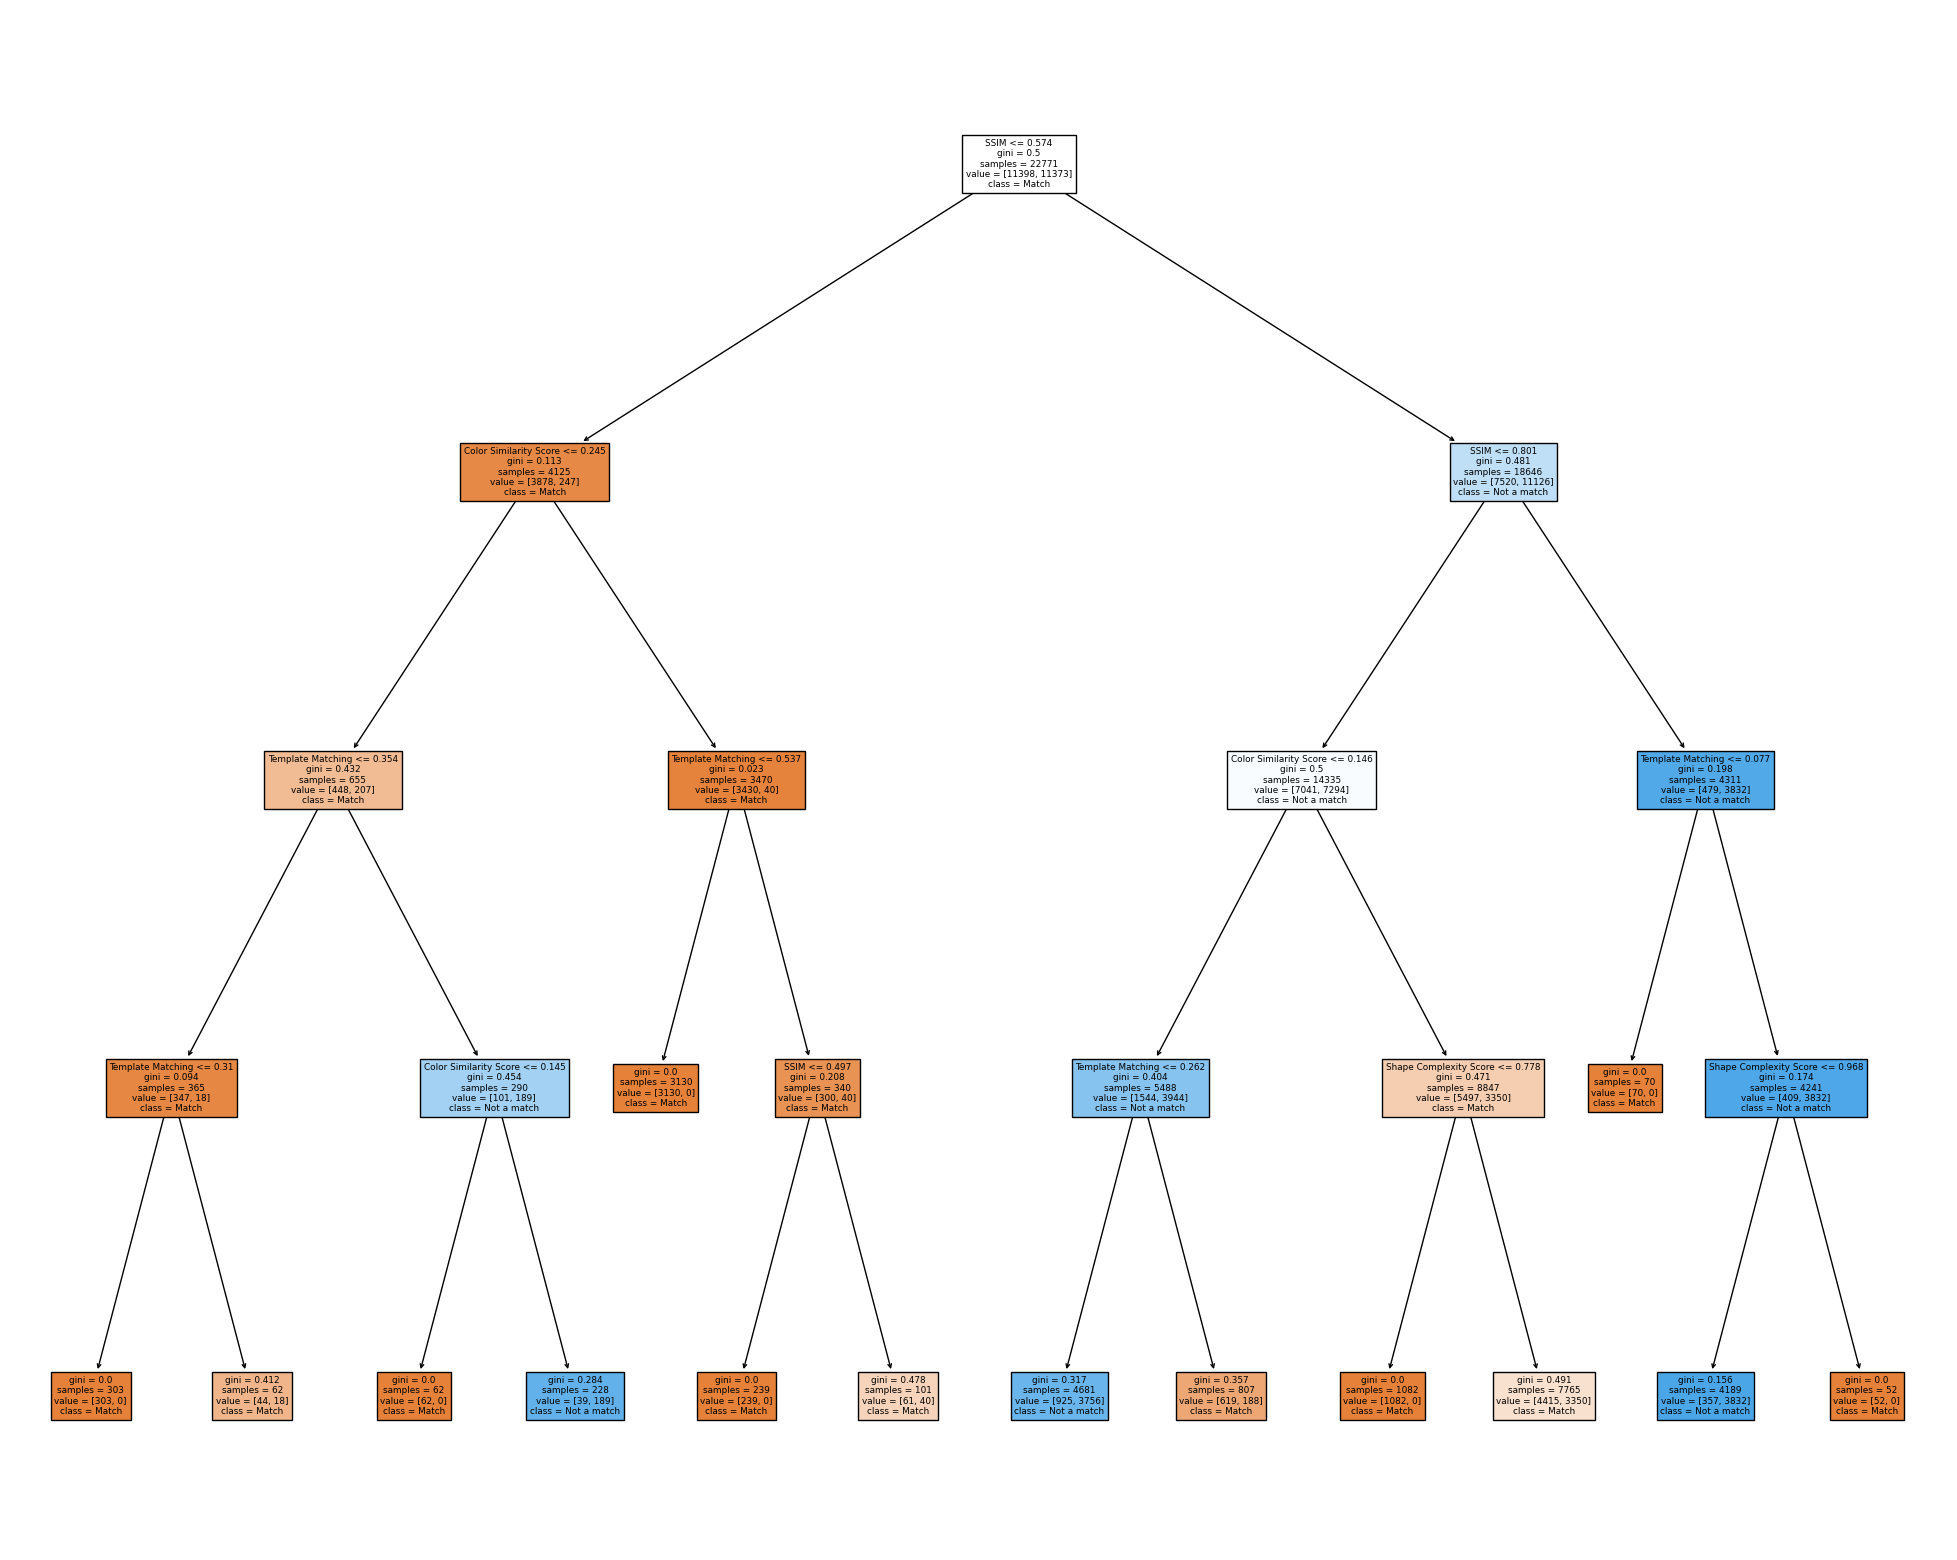

In [98]:
fig = plt.figure(figsize=(25,20))
_ = tree.plot_tree(dtc, 
                   feature_names=features,  
                   class_names=['Match', 'Not a match'],
                   filled=True)

## Random Forest Classifier

In [50]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate, cross_val_score, cross_val_predict
from sklearn.metrics import confusion_matrix

In [51]:
rfc = RandomForestClassifier()
rfc.fit(X_train, y_train)
y_pred = rfc.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

conf_matrix = confusion_matrix(y_test, y_pred)
print('There are {} false positives and {} false negatives'.format(conf_matrix[0][1], conf_matrix[1][0]))

Accuracy: 0.9903390128227648
There are 45 false positives and 10 false negatives


### K fold cross validation fine tuning

In [52]:
# N estimators fine tuning (default = 100, others: int)
for n in [5, 10, 20, 30, 100, 200]:
    k_pred = cross_val_predict(RandomForestClassifier(n_estimators=n), X_train, y_train, cv=10)
    conf = confusion_matrix(y_train, k_pred)
    print('{} estimators model: total number of errors is {}, and number of recalls is {}'.format(n, conf[0][1]+conf[1][0], conf[1][0]))

5 estimators model: total number of errors is 434, and number of recalls is 99
10 estimators model: total number of errors is 318, and number of recalls is 57
20 estimators model: total number of errors is 296, and number of recalls is 40
30 estimators model: total number of errors is 293, and number of recalls is 35
100 estimators model: total number of errors is 292, and number of recalls is 25
200 estimators model: total number of errors is 295, and number of recalls is 23


In [53]:
# criterion fine tuning (default=”gini”, others: “entropy”, “log_loss”)
for crit in ["gini", "entropy", "log_loss"]:
    k_pred = cross_val_predict(RandomForestClassifier(criterion=crit), X_train, y_train, cv=10)
    conf = confusion_matrix(y_train, k_pred)
    print('{} criterion model: total number of errors is {}, and number of recalls is {}'.format(crit, conf[0][1]+conf[1][0], conf[1][0]))

gini criterion model: total number of errors is 282, and number of recalls is 25
entropy criterion model: total number of errors is 298, and number of recalls is 26
log_loss criterion model: total number of errors is 300, and number of recalls is 22


In [55]:
# max_depth fine tuning, (default=None, others: int)
for dep in [5, 10, 20, 30, 100]:
    k_pred = cross_val_predict(RandomForestClassifier(max_depth = dep), X_train, y_train, cv=10)
    conf = confusion_matrix(y_train, k_pred)
    print('{} depth model: total number of errors is {}, and number of recalls is {}'.format(dep, conf[0][1]+conf[1][0], conf[1][0]))

In [ ]:
# max_features, (default = sqrt, others: “log2”, int)
for n_feat in ["sqrt", 4]:
    k_pred = cross_val_predict(RandomForestClassifier(max_features = n_feat), X_train, y_train, cv=10)
    conf = confusion_matrix(y_train, k_pred)
    print('{} features model: total number of errors is {}, and number of recalls is {}'.format(n_feat, conf[0][1]+conf[1][0], conf[1][0]))

In [ ]:
X_test.shape

In [56]:
rfc_isotonic = CalibratedClassifierCV(RandomForestClassifier(), method='isotonic')
rfc_isotonic.fit(X_train, y_train)
y_pred = rfc_isotonic.predict(X_test)
conf = confusion_matrix(y_test, y_pred)
print('Total number of errors is {}, and number of recalls is {}'.format(conf[0][1]+conf[1][0], conf[1][0]))

Total number of errors is 48, and number of recalls is 20


## Tuning the probability

In [104]:
rfc_isotonic = CalibratedClassifierCV(RandomForestClassifier(), method='isotonic')
rfc_isotonic.fit(X_train, y_train)
y_pred = rfc_isotonic.predict_proba(X_test)
y_pred

array([[2.63073716e-03, 9.97369263e-01],
       [9.21206349e-01, 7.87936508e-02],
       [1.05097524e-02, 9.89490248e-01],
       ...,
       [7.98990655e-04, 9.99201009e-01],
       [1.98710947e-03, 9.98012891e-01],
       [1.00000000e+00, 0.00000000e+00]])

In [126]:
y_exp = (y_pred[:,1] >= 0.995).astype(bool)

In [127]:
confusion_matrix(y_exp, y_test)

array([[2833,  755],
       [   1, 2104]])